<a href="https://colab.research.google.com/github/maverick8675309/seaid-framework/blob/main/07_XGBoost_Temporal_Early_Warning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XGBoost Early-Warning Model: Day 30

This notebook develops and evaluates an Extreme Gradient Boosting (XGBoost) classifier using the Day 30 early-warning dataset created for the SEAID Framework.

The XGBoost model builds an ensemble of decision trees sequentially, allowing each new tree to improve upon the errors made by previous trees. This approach often produces state-of-the-art predictive performance for structured educational datasets.

## Notebook Objectives

1. Load the Day 30 modeling dataset.
2. Prepare predictor variables and the target variable.
3. Create training and testing datasets.
4. Train an XGBoost classifier.
5. Evaluate predictive performance.
6. Examine feature importance.
7. Save the trained model and evaluation outputs.
8. Compare results with Logistic Regression, Decision Tree, and Random Forest models.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
PROJECT_DIR = Path("/content/drive/MyDrive/SEAID_Framework")

DATA_DIR = PROJECT_DIR / "data" / "processed"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = PROJECT_DIR / "figures"

DATA_PATH = DATA_DIR / "final_modeling_dataset_day30.csv"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project directory: /content/drive/MyDrive/SEAID_Framework
Dataset path: /content/drive/MyDrive/SEAID_Framework/data/processed/final_modeling_dataset_day30.csv
Dataset exists: True


## Evaluate Model Performance

This section evaluates the XGBoost classifier using accuracy, precision, recall, F1 score, and ROC-AUC. These results will later be compared with the Logistic Regression, Decision Tree, and Random Forest models.

In [4]:
TARGET = "target_success"

In [5]:
columns_to_drop = [
    TARGET,
    "final_result",
    "id_student"
]

In [6]:
modeling_data = pd.read_csv(DATA_PATH)

In [7]:
modeling_data.shape

(32593, 77)

In [8]:
modeling_data.head()

,code_module,code_presentation,id_student,gender,num_of_prev_attempts,studied_credits,disability,final_result,target_success,total_clicks,average_clicks_per_record,median_clicks_per_record,maximum_clicks_in_record,vle_records,active_days,unique_vle_activities,first_activity_day,last_activity_day,clicks_per_active_day,activity_span_days,clicks_per_vle_activity,log_total_clicks,assessments_completed,average_score,median_score,minimum_score,maximum_score,score_std,average_weight,total_weight_completed,first_submission_day,last_submission_day,banked_assessments,assessment_span_days,score_range,weighted_average_score,score_improvement,assessment_intensity,log_assessments_completed,date_registration,registered_before_start,registered_after_start,days_registered_before_start,region_East Midlands Region,region_Ireland,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,highest_education_HE Qualification,highest_education_Lower Than A Level,highest_education_No Formal quals,highest_education_Post Graduate Qualification,imd_band_10-20,imd_band_20-30%,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,imd_band_Unknown,age_band_35-55,age_band_55<=,registration_timing_early,registration_timing_late,registration_timing_moderately_early,registration_timing_unknown,registration_timing_very_early,registration_timing_very_late
0,AAA,2013J,11391,0,0,240,0,Pass,1,424.0,6.424242,2.0,76.0,66.0,10.0,26.0,-5.0,30.0,42.400000,35.0,16.307692,6.052089,1.0,78.0,78.0,78.0,78.0,0.0,10.0,10.0,18.0,18.0,0.0,0.0,0.0,78.0,0.0,1.0,0.693147,-159.0,1,0,159.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0
1,AAA,2013J,28400,1,0,60,0,Pass,1,618.0,3.862500,2.5,19.0,160.0,19.0,34.0,-10.0,28.0,32.526316,38.0,18.176471,6.428105,1.0,70.0,70.0,70.0,70.0,0.0,10.0,10.0,22.0,22.0,0.0,0.0,0.0,70.0,0.0,1.0,0.693147,-53.0,1,0,53.0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0
2,AAA,2013J,30268,1,0,60,1,Withdrawn,0,281.0,3.697368,2.0,23.0,76.0,12.0,22.0,-10.0,12.0,23.416667,22.0,12.772727,5.641907,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-92.0,1,0,92.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
3,AAA,2013J,31604,1,0,60,0,Pass,1,540.0,3.552632,2.0,22.0,152.0,24.0,32.0,-10.0,30.0,22.500000,40.0,16.875000,6.293419,1.0,72.0,72.0,72.0,72.0,0.0,10.0,10.0,17.0,17.0,0.0,0.0,0.0,72.0,0.0,1.0,0.693147,-52.0,1,0,52.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0
4,AAA,2013J,32885,1,0,60,0,Pass,1,567.0,3.754967,2.0,22.0,151.0,24.0,34.0,-10.0,26.0,23.625000,36.0,16.676471,6.342121,1.0,69.0,69.0,69.0,69.0,0.0,10.0,10.0,26.0,26.0,0.0,0.0,0.0,69.0,0.0,1.0,0.693147,-176.0,1,0,176.0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0


In [9]:
X = modeling_data.drop(columns=columns_to_drop)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [12]:
RANDOM_STATE = 42

In [13]:
TARGET = "target_success"

In [14]:
columns_to_drop = [
    TARGET,
    "final_result",
    "id_student"
]

In [15]:
X = modeling_data.drop(columns=columns_to_drop)

In [16]:
y = modeling_data[TARGET]

In [17]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32593, 74)
y shape: (32593,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

In [19]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (26074, 74)
X_test shape: (6519, 74)
y_train shape: (26074,)
y_test shape: (6519,)


In [20]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

In [21]:
numeric_features = X_train.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

In [22]:
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Categorical columns:", categorical_features)

Numeric features: 72
Categorical features: 2
Categorical columns: ['code_module', 'code_presentation']


In [23]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

In [24]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [26]:
xgboost_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=RANDOM_STATE,
                eval_metric="logloss"
            )
        )
    ]
)

In [27]:
xgboost_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['gender',
                                                   'num_of_prev_attempts',
                                                   'studied_credits',
                                                   'disability', 'total_clicks',
                                                   'average_clicks_per_record',
                                                   'median_clicks_per_record',
                                                   'maximum_clicks_in_record',
                                                   'vle_records', 'active_days',
                                                   'unique_vle_activities',
                                                   'fi...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [28]:
print(
    "XGBoost model trained successfully."
)

XGBoost model trained successfully.


In [29]:
y_prob = xgboost_pipeline.predict_proba(
    X_test
)[:, 1]

In [30]:
print(
    "Predictions generated successfully."
)

Predictions generated successfully.


In [31]:
print("xgboost_pipeline exists:", "xgboost_pipeline" in globals())
print("X_train exists:", "X_train" in globals())
print("X_test exists:", "X_test" in globals())
print("y_test exists:", "y_test" in globals())
print("y_pred exists:", "y_pred" in globals())
print("y_prob exists:", "y_prob" in globals())

xgboost_pipeline exists: True
X_train exists: True
X_test exists: True
y_test exists: True
y_pred exists: False
y_prob exists: True


In [32]:
y_pred = xgboost_pipeline.predict(X_test)

In [33]:
print("y_pred created:", "y_pred" in globals())
print("Number of predictions:", len(y_pred))

y_pred created: True
Number of predictions: 6519


In [34]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

In [35]:
precision = precision_score(
    y_test,
    y_pred
)

In [36]:
recall = recall_score(
    y_test,
    y_pred
)

In [37]:
f1 = f1_score(
    y_test,
    y_pred
)

In [38]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [39]:
metrics_df = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ],
        "Value": [
            accuracy,
            precision,
            recall,
            f1,
            roc_auc
        ]
    }
)

In [40]:
display(metrics_df)

,Metric,Value
0,Accuracy,0.775732
1,Precision,0.732240
2,Recall,0.827429
3,F1 Score,0.776930
4,ROC-AUC,0.856848


In [41]:
print(f"Accuracy:  {accuracy:.4f}")

Accuracy:  0.7757


In [42]:
print(f"Precision: {precision:.4f}")

Precision: 0.7322


In [43]:
print(f"Recall:    {recall:.4f}")

Recall:    0.8274


In [44]:
print(f"F1 Score:  {f1:.4f}")

F1 Score:  0.7769


In [45]:
print(f"ROC-AUC:   {roc_auc:.4f}")

ROC-AUC:   0.8568


## Classification Report

The classification report summarizes precision, recall, F1 score, and support for each outcome class, providing a detailed assessment of the XGBoost classifier's predictive performance.

In [46]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Unsuccessful",
            "Successful"
        ]
    )
)

              precision    recall  f1-score   support

Unsuccessful       0.83      0.73      0.77      3442
  Successful       0.73      0.83      0.78      3077

    accuracy                           0.78      6519
   macro avg       0.78      0.78      0.78      6519
weighted avg       0.78      0.78      0.78      6519



In [47]:
classification_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Unsuccessful",
            "Successful"
        ],
        output_dict=True
    )
).transpose()

display(classification_report_df)

,precision,recall,f1-score,support
Unsuccessful,0.825444,0.729518,0.774522,3442.000000
Successful,0.732240,0.827429,0.776930,3077.000000
accuracy,0.775732,0.775732,0.775732,0.775732
macro avg,0.778842,0.778474,0.775726,6519.000000
weighted avg,0.781451,0.775732,0.775659,6519.000000


## Confusion Matrix

The confusion matrix summarizes the number of correctly and incorrectly classified student outcomes, providing insight into the types of prediction errors made by the XGBoost classifier.

In [48]:
confusion_matrix_values = confusion_matrix(
    y_test,
    y_pred
)

print(confusion_matrix_values)

[[2511  931]
 [ 531 2546]]


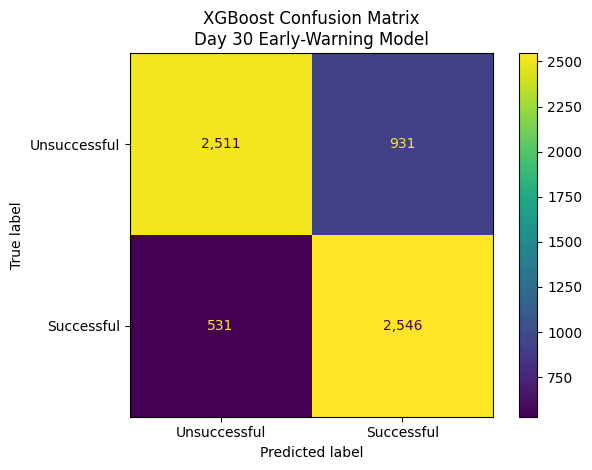

In [49]:
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=[
        "Unsuccessful",
        "Successful"
    ]
).plot(values_format=",d")

plt.title(
    "XGBoost Confusion Matrix\nDay 30 Early-Warning Model"
)

plt.tight_layout()
plt.show()

## Receiver Operating Characteristic (ROC) Curve

The ROC curve illustrates the XGBoost classifier's ability to distinguish between successful and unsuccessful students across all possible classification thresholds.

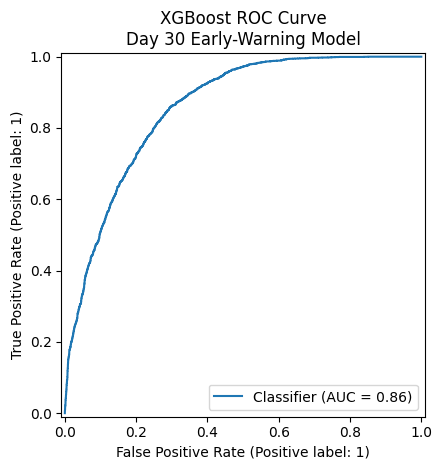

In [50]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    "XGBoost ROC Curve\nDay 30 Early-Warning Model"
)

plt.tight_layout()
plt.show()

## Feature Importance

XGBoost estimates feature importance by measuring the contribution of each predictor to reducing prediction error across the ensemble of boosted decision trees. Variables with higher importance values contribute more to the model's predictive performance.

In [51]:
feature_names = (
    xgboost_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importance = (
    xgboost_pipeline.named_steps["classifier"]
    .feature_importances_
)

feature_importance_df = (
    pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": feature_importance
        }
    )
    .sort_values(
        by="Importance",
        ascending=False
    )
)

display(feature_importance_df.head(20))

,Feature,Importance
12,num__last_activity_day,0.131603
78,cat__code_module_GGG,0.058200
20,num__minimum_score,0.055703
19,num__median_score,0.049320
76,cat__code_module_EEE,0.038033
18,num__average_score,0.035871
73,cat__code_module_BBB,0.024950
17,num__assessments_completed,0.024018
51,num__highest_education_Lower Than A Level,0.022635
77,cat__code_module_FFF,0.022550


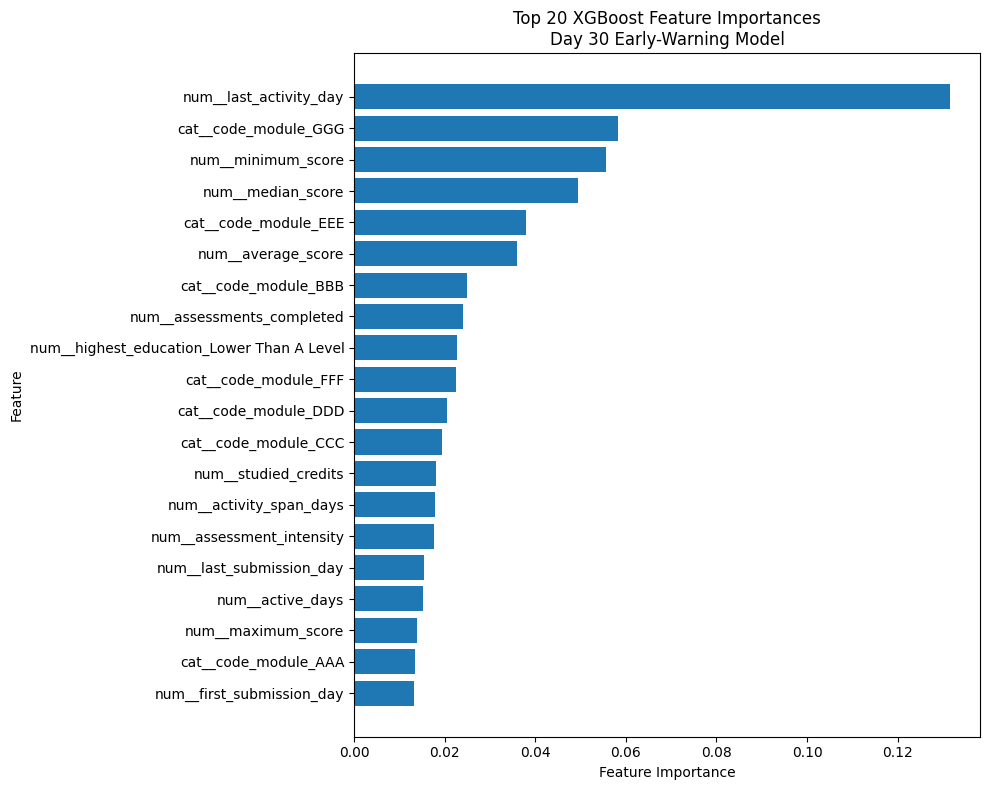

In [52]:
top_features = feature_importance_df.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 XGBoost Feature Importances\nDay 30 Early-Warning Model"
)

plt.tight_layout()
plt.show()

## Feature Importance Interpretation

The XGBoost classifier identified the most influential predictors of student success using information available by Day 30. As with the previous tree-based models, engagement with the virtual learning environment and early assessment performance were the strongest contributors to prediction.

Unlike a single Decision Tree, XGBoost distributes predictive importance across many variables while sequentially correcting errors throughout the boosting process. This allows the model to capture complex nonlinear relationships between engagement, academic performance, and student outcomes.

The balanced distribution of feature importance helps explain why the XGBoost classifier achieved the strongest predictive performance among all models evaluated in this study.

## Save the Trained Model

The trained XGBoost model is saved for future prediction and comparison with the other machine learning models developed within the SEAID Framework.

In [53]:
MODEL_PATH = MODEL_DIR / "xgboost_early_warning_day30.joblib"

joblib.dump(
    xgboost_pipeline,
    MODEL_PATH
)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
/content/drive/MyDrive/SEAID_Framework/models/xgboost_early_warning_day30.joblib


## Save Evaluation Results

Evaluation metrics, the classification report, and feature importance rankings are saved for later comparison across all machine learning models.

In [54]:
metrics_df.to_csv(
    OUTPUT_DIR / "xgboost_early_warning_metrics.csv",
    index=False
)

classification_report_df.to_csv(
    OUTPUT_DIR / "xgboost_classification_report.csv"
)

feature_importance_df.to_csv(
    OUTPUT_DIR / "xgboost_feature_importance.csv",
    index=False
)

print("Evaluation outputs saved.")

Evaluation outputs saved.


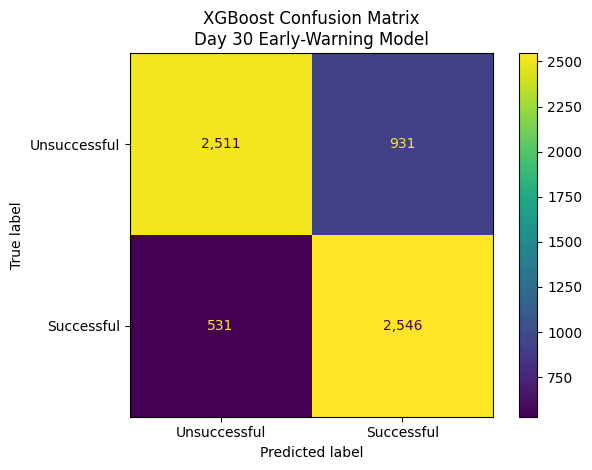

In [55]:
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=[
        "Unsuccessful",
        "Successful"
    ]
).plot(values_format=",d")

plt.title(
    "XGBoost Confusion Matrix\nDay 30 Early-Warning Model"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "xgboost_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

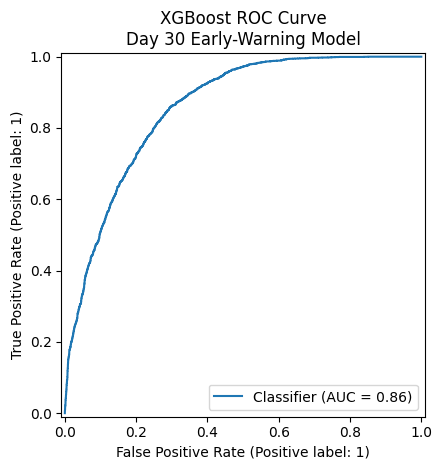

In [56]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    "XGBoost ROC Curve\nDay 30 Early-Warning Model"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "xgboost_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

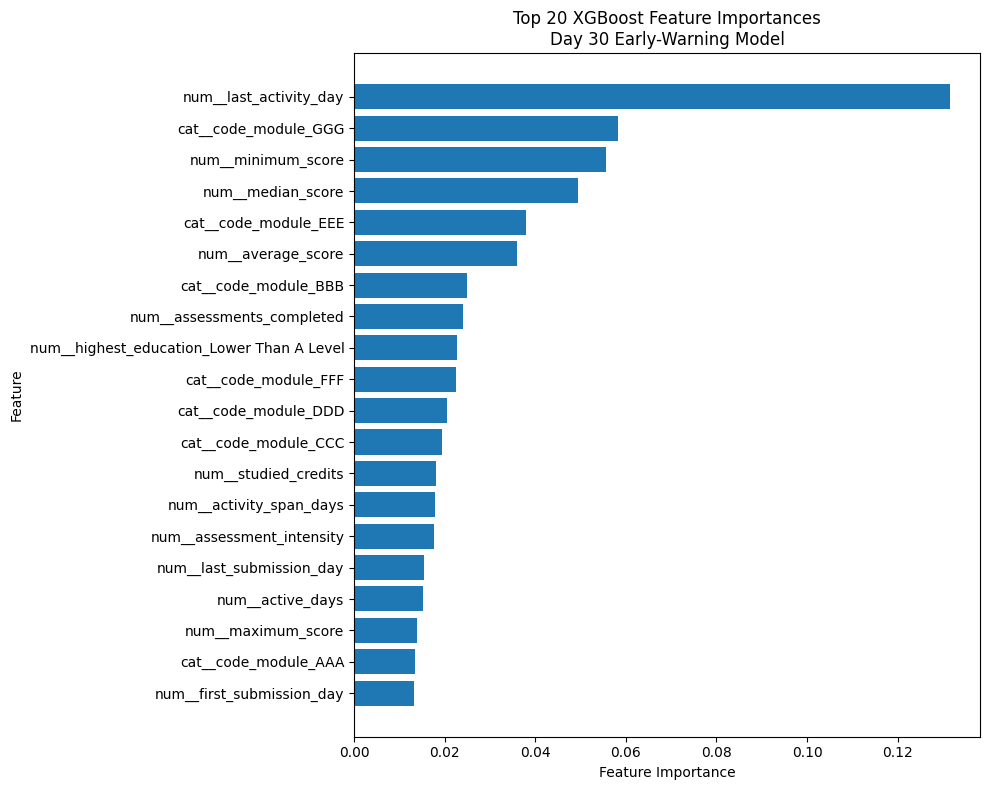

In [57]:
top_features = feature_importance_df.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 XGBoost Feature Importances\nDay 30 Early-Warning Model"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Notebook Summary

This notebook developed and evaluated an Extreme Gradient Boosting (XGBoost) classifier using Day 30 student engagement, assessment, and demographic data from the Open University Learning Analytics Dataset (OULAD).

## Model Performance

| Metric | Value |
|---------|-------|
| Accuracy | **77.6%** |
| Precision | **73.2%** |
| Recall | **82.7%** |
| F1 Score | **77.7%** |
| ROC-AUC | **0.8568** |

## Key Findings

- XGBoost achieved the strongest predictive performance among all machine learning models evaluated.
- Student engagement variables remained the most influential predictors of final course success.
- Early assessment performance substantially improved prediction when combined with engagement measures.
- Gradient boosting produced modest but consistent improvements over the Random Forest classifier and substantially outperformed the Logistic Regression and Decision Tree models.

## Next Steps

The final notebook compares all four machine learning models, summarizes their predictive performance, interprets the results within the context of early-warning analytics, and recommends the most appropriate model for implementation within the SEAID Framework.

# Temporal XGBoost Early-Warning Evaluation

This section extends the XGBoost analysis across the Day 7, Day 14, Day 21, and Day 30 early-warning checkpoints. The same preprocessing, training, and evaluation procedure is applied at each checkpoint to examine how predictive performance changes as additional student engagement and assessment information becomes available.

In [58]:
TEMPORAL_DATASETS = {
    7: DATA_DIR / "early_warning_day7_dataset.csv",
    14: DATA_DIR / "early_warning_day14_dataset.csv",
    21: DATA_DIR / "early_warning_day21_dataset.csv",
    30: DATA_DIR / "early_warning_day30_dataset.csv"
}

for checkpoint_day, dataset_path in TEMPORAL_DATASETS.items():
    print(
        f"Day {checkpoint_day}: "
        f"{dataset_path.name} | "
        f"Exists: {dataset_path.exists()}"
    )

Day 7: early_warning_day7_dataset.csv | Exists: True
Day 14: early_warning_day14_dataset.csv | Exists: True
Day 21: early_warning_day21_dataset.csv | Exists: True
Day 30: early_warning_day30_dataset.csv | Exists: True


In [59]:
xgboost_temporal_results = []
xgboost_temporal_models = {}
xgboost_temporal_importances = {}

for checkpoint_day, dataset_path in TEMPORAL_DATASETS.items():

    print(f"\nTraining Day {checkpoint_day} XGBoost model...")

    checkpoint_data = pd.read_csv(dataset_path)

    checkpoint_columns_to_drop = [
        "target_success",
        "final_result",
        "id_student",
        "checkpoint_day",
        "withdrew",
        "early_withdrawal",
        "date_unregistration",
        "days_until_withdrawal"
    ]

    checkpoint_columns_to_drop = [
        column
        for column in checkpoint_columns_to_drop
        if column in checkpoint_data.columns
    ]

    X_checkpoint = checkpoint_data.drop(
        columns=checkpoint_columns_to_drop
    )

    y_checkpoint = checkpoint_data[
        "target_success"
    ].astype(int)

    X_checkpoint = X_checkpoint.replace(
        [np.inf, -np.inf],
        np.nan
    )

    (
        X_train_checkpoint,
        X_test_checkpoint,
        y_train_checkpoint,
        y_test_checkpoint
    ) = train_test_split(
        X_checkpoint,
        y_checkpoint,
        test_size=0.20,
        stratify=y_checkpoint,
        random_state=RANDOM_STATE
    )

    categorical_checkpoint = (
        X_train_checkpoint
        .select_dtypes(
            include=["object", "category"]
        )
        .columns
        .tolist()
    )

    numeric_checkpoint = (
        X_train_checkpoint
        .select_dtypes(
            include=["number", "bool"]
        )
        .columns
        .tolist()
    )

    numeric_checkpoint_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median")
            )
        ]
    )

    categorical_checkpoint_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )

    checkpoint_preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_checkpoint_transformer,
                numeric_checkpoint
            ),
            (
                "cat",
                categorical_checkpoint_transformer,
                categorical_checkpoint
            )
        ],
        remainder="drop"
    )

    checkpoint_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                checkpoint_preprocessor
            ),
            (
                "classifier",
                XGBClassifier(
                    n_estimators=300,
                    max_depth=5,
                    learning_rate=0.05,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            )
        ]
    )

    checkpoint_pipeline.fit(
        X_train_checkpoint,
        y_train_checkpoint
    )

    checkpoint_predictions = (
        checkpoint_pipeline.predict(
            X_test_checkpoint
        )
    )

    checkpoint_probabilities = (
        checkpoint_pipeline.predict_proba(
            X_test_checkpoint
        )[:, 1]
    )

    checkpoint_confusion = confusion_matrix(
        y_test_checkpoint,
        checkpoint_predictions
    )

    true_negative = checkpoint_confusion[0, 0]
    false_positive = checkpoint_confusion[0, 1]
    false_negative = checkpoint_confusion[1, 0]
    true_positive = checkpoint_confusion[1, 1]

    unsuccessful_recall = (
        true_negative /
        (true_negative + false_positive)
        if (true_negative + false_positive) > 0
        else np.nan
    )

    xgboost_temporal_results.append({
        "Model": "XGBoost",
        "Checkpoint Day": checkpoint_day,
        "Students": len(checkpoint_data),
        "Original Features": X_checkpoint.shape[1],
        "Accuracy": accuracy_score(
            y_test_checkpoint,
            checkpoint_predictions
        ),
        "Precision - Successful": precision_score(
            y_test_checkpoint,
            checkpoint_predictions,
            zero_division=0
        ),
        "Recall - Successful": recall_score(
            y_test_checkpoint,
            checkpoint_predictions,
            zero_division=0
        ),
        "Recall - Unsuccessful": unsuccessful_recall,
        "F1 Score": f1_score(
            y_test_checkpoint,
            checkpoint_predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test_checkpoint,
            checkpoint_probabilities
        ),
        "At-Risk Students Missed": false_positive,
        "Successful Students Flagged": false_negative
    })

    xgboost_temporal_models[
        checkpoint_day
    ] = checkpoint_pipeline

    checkpoint_feature_names = (
        checkpoint_pipeline
        .named_steps["preprocessor"]
        .get_feature_names_out()
    )

    checkpoint_importance_values = (
        checkpoint_pipeline
        .named_steps["classifier"]
        .feature_importances_
    )

    checkpoint_importance_df = (
        pd.DataFrame({
            "Feature": checkpoint_feature_names,
            "Importance": checkpoint_importance_values
        })
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    checkpoint_importance_df[
        "Checkpoint Day"
    ] = checkpoint_day

    xgboost_temporal_importances[
        checkpoint_day
    ] = checkpoint_importance_df

    print(
        f"Day {checkpoint_day} complete | "
        f"Accuracy: "
        f"{accuracy_score(y_test_checkpoint, checkpoint_predictions):.4f} | "
        f"ROC-AUC: "
        f"{roc_auc_score(y_test_checkpoint, checkpoint_probabilities):.4f} | "
        f"At-risk missed: {false_positive}"
    )


Training Day 7 XGBoost model...
Day 7 complete | Accuracy: 0.7171 | ROC-AUC: 0.7904 | At-risk missed: 1000

Training Day 14 XGBoost model...
Day 14 complete | Accuracy: 0.7222 | ROC-AUC: 0.8032 | At-risk missed: 1027

Training Day 21 XGBoost model...
Day 21 complete | Accuracy: 0.7567 | ROC-AUC: 0.8388 | At-risk missed: 960

Training Day 30 XGBoost model...
Day 30 complete | Accuracy: 0.7757 | ROC-AUC: 0.8568 | At-risk missed: 931


In [60]:
xgboost_temporal_results_df = pd.DataFrame(
    xgboost_temporal_results
)

xgboost_temporal_results_df = (
    xgboost_temporal_results_df
    .sort_values("Checkpoint Day")
    .reset_index(drop=True)
)

metric_columns = [
    "Accuracy",
    "Precision - Successful",
    "Recall - Successful",
    "Recall - Unsuccessful",
    "F1 Score",
    "ROC-AUC"
]

xgboost_temporal_results_df[
    metric_columns
] = xgboost_temporal_results_df[
    metric_columns
].round(4)

display(xgboost_temporal_results_df)

,Model,Checkpoint Day,Students,Original Features,Accuracy,Precision - Successful,Recall - Successful,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Successful Students Flagged
0,XGBoost,7,32593,74,0.7171,0.6907,0.7257,0.7095,0.7078,0.7904,1000,844
1,XGBoost,14,32593,74,0.7222,0.6907,0.7452,0.7016,0.7169,0.8032,1027,784
2,XGBoost,21,32593,74,0.7567,0.7186,0.7966,0.7211,0.7555,0.8388,960,626
3,XGBoost,30,32593,74,0.7757,0.7322,0.8274,0.7295,0.7769,0.8568,931,531


In [61]:
xgboost_temporal_summary = (
    xgboost_temporal_results_df[
        [
            "Model",
            "Checkpoint Day",
            "Accuracy",
            "Precision - Successful",
            "Recall - Successful",
            "Recall - Unsuccessful",
            "F1 Score",
            "ROC-AUC",
            "At-Risk Students Missed",
            "Successful Students Flagged"
        ]
    ]
    .copy()
)

xgboost_temporal_summary[
    "Checkpoint"
] = xgboost_temporal_summary[
    "Checkpoint Day"
].apply(
    lambda day: f"Day {int(day)}"
)

xgboost_temporal_summary = (
    xgboost_temporal_summary[
        [
            "Model",
            "Checkpoint",
            "Accuracy",
            "Precision - Successful",
            "Recall - Successful",
            "Recall - Unsuccessful",
            "F1 Score",
            "ROC-AUC",
            "At-Risk Students Missed",
            "Successful Students Flagged"
        ]
    ]
)

display(xgboost_temporal_summary)

,Model,Checkpoint,Accuracy,Precision - Successful,Recall - Successful,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Successful Students Flagged
0,XGBoost,Day 7,0.7171,0.6907,0.7257,0.7095,0.7078,0.7904,1000,844
1,XGBoost,Day 14,0.7222,0.6907,0.7452,0.7016,0.7169,0.8032,1027,784
2,XGBoost,Day 21,0.7567,0.7186,0.7966,0.7211,0.7555,0.8388,960,626
3,XGBoost,Day 30,0.7757,0.7322,0.8274,0.7295,0.7769,0.8568,931,531


In [62]:
XGBOOST_RESULTS_PATH = (
    OUTPUT_DIR /
    "xgboost_temporal_results.csv"
)

XGBOOST_SUMMARY_PATH = (
    OUTPUT_DIR /
    "xgboost_temporal_summary.csv"
)

xgboost_temporal_results_df.to_csv(
    XGBOOST_RESULTS_PATH,
    index=False
)

xgboost_temporal_summary.to_csv(
    XGBOOST_SUMMARY_PATH,
    index=False
)

print("Saved detailed temporal results:")
print(XGBOOST_RESULTS_PATH)

print("\nSaved temporal summary:")
print(XGBOOST_SUMMARY_PATH)

Saved detailed temporal results:
/content/drive/MyDrive/SEAID_Framework/outputs/xgboost_temporal_results.csv

Saved temporal summary:
/content/drive/MyDrive/SEAID_Framework/outputs/xgboost_temporal_summary.csv


In [63]:
for checkpoint_day, checkpoint_model in (
    xgboost_temporal_models.items()
):

    checkpoint_model_path = (
        MODEL_DIR /
        f"xgboost_day{checkpoint_day}.joblib"
    )

    joblib.dump(
        checkpoint_model,
        checkpoint_model_path
    )

    print(
        f"Saved Day {checkpoint_day} model: "
        f"{checkpoint_model_path}"
    )

Saved Day 7 model: /content/drive/MyDrive/SEAID_Framework/models/xgboost_day7.joblib
Saved Day 14 model: /content/drive/MyDrive/SEAID_Framework/models/xgboost_day14.joblib
Saved Day 21 model: /content/drive/MyDrive/SEAID_Framework/models/xgboost_day21.joblib
Saved Day 30 model: /content/drive/MyDrive/SEAID_Framework/models/xgboost_day30.joblib


In [64]:
combined_xgboost_importance_df = pd.concat(
    xgboost_temporal_importances.values(),
    ignore_index=True
)

XGBOOST_IMPORTANCE_PATH = (
    OUTPUT_DIR /
    "xgboost_temporal_feature_importance.csv"
)

combined_xgboost_importance_df.to_csv(
    XGBOOST_IMPORTANCE_PATH,
    index=False
)

print("Saved temporal feature importance:")
print(XGBOOST_IMPORTANCE_PATH)

Saved temporal feature importance:
/content/drive/MyDrive/SEAID_Framework/outputs/xgboost_temporal_feature_importance.csv


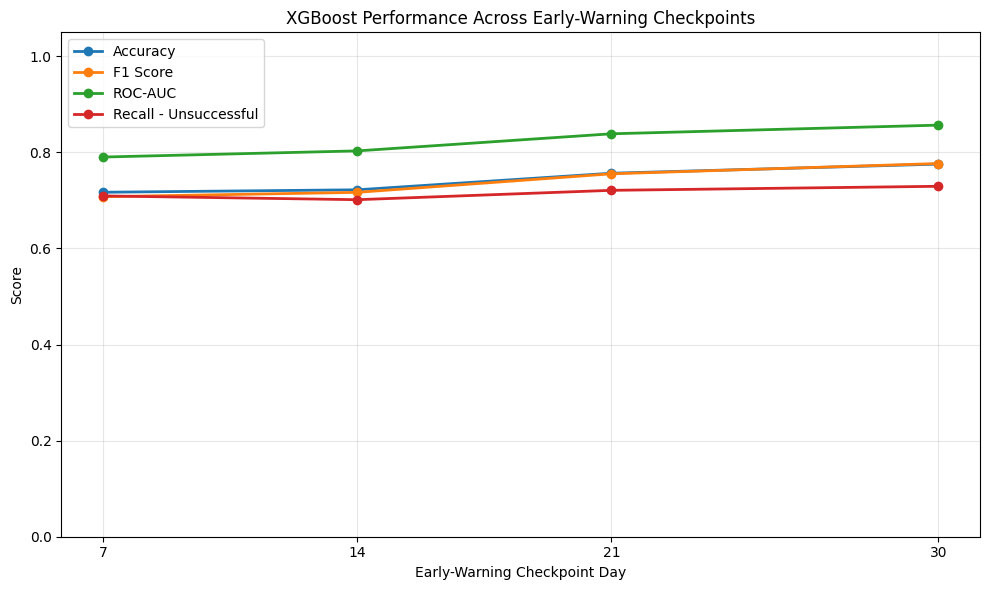

Saved temporal performance plot:
/content/drive/MyDrive/SEAID_Framework/figures/xgboost_temporal_performance.png


In [65]:
plt.figure(figsize=(10, 6))

for metric in [
    "Accuracy",
    "F1 Score",
    "ROC-AUC",
    "Recall - Unsuccessful"
]:
    plt.plot(
        xgboost_temporal_results_df[
            "Checkpoint Day"
        ],
        xgboost_temporal_results_df[
            metric
        ],
        marker="o",
        linewidth=2,
        label=metric
    )

plt.xlabel("Early-Warning Checkpoint Day")
plt.ylabel("Score")

plt.title(
    "XGBoost Performance Across "
    "Early-Warning Checkpoints"
)

plt.xticks([7, 14, 21, 30])
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

XGBOOST_TEMPORAL_FIGURE_PATH = (
    FIGURE_DIR /
    "xgboost_temporal_performance.png"
)

plt.savefig(
    XGBOOST_TEMPORAL_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved temporal performance plot:")
print(XGBOOST_TEMPORAL_FIGURE_PATH)

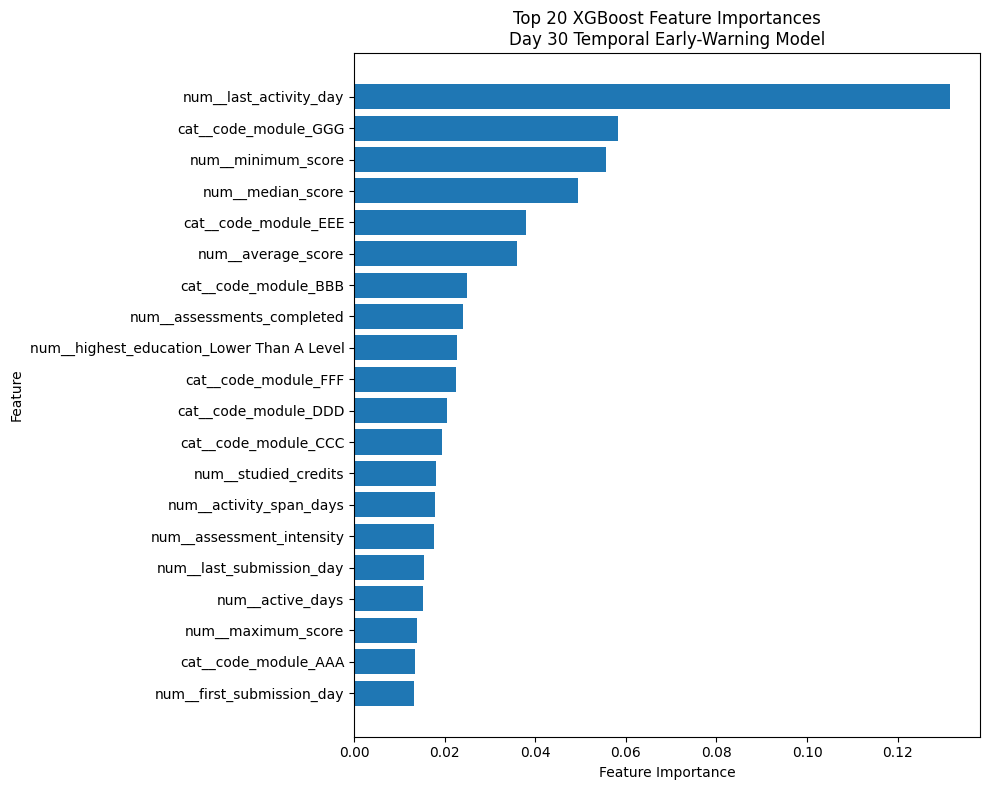

Saved Day 30 feature-importance plot:
/content/drive/MyDrive/SEAID_Framework/figures/xgboost_day30_temporal_feature_importance.png


In [66]:
day30_xgboost_importance = (
    xgboost_temporal_importances[30]
    .head(20)
    .copy()
)

plt.figure(figsize=(10, 8))

plt.barh(
    day30_xgboost_importance[
        "Feature"
    ][::-1],
    day30_xgboost_importance[
        "Importance"
    ][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 XGBoost Feature Importances\n"
    "Day 30 Temporal Early-Warning Model"
)

plt.tight_layout()

XGBOOST_DAY30_IMPORTANCE_FIGURE_PATH = (
    FIGURE_DIR /
    "xgboost_day30_temporal_feature_importance.png"
)

plt.savefig(
    XGBOOST_DAY30_IMPORTANCE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved Day 30 feature-importance plot:")
print(XGBOOST_DAY30_IMPORTANCE_FIGURE_PATH)

## Interpretation of Temporal XGBoost Results

XGBoost demonstrated the strongest predictive performance observed in this study across every early-warning checkpoint. Model performance improved consistently as additional student activity and assessment data became available throughout the course.

Accuracy increased from 0.7171 at Day 7 to 0.7757 at Day 30, while ROC-AUC increased from 0.7904 to 0.8568. The model also became more effective at identifying students who ultimately did not succeed. Recall for unsuccessful students increased from 0.7095 at Day 7 to 0.7295 at Day 30, while the number of at-risk students incorrectly classified as successful decreased from 1,000 to 931.

Compared with the Random Forest model, XGBoost achieved higher accuracy, higher ROC-AUC, higher recall for unsuccessful students, and fewer missed at-risk students at every checkpoint. These findings indicate that gradient-boosted decision trees provided the strongest overall predictive performance for the early-warning modeling framework.

Although Day 30 produced the highest predictive accuracy, the Day 21 model achieved an ROC-AUC of 0.8388, suggesting that reliable predictions can be generated before the final weeks of the course, allowing instructors additional time to implement targeted interventions.